<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предсказание победителя матча CS2

**Задача:** для двух выбранных команд оценить вероятность победы каждой на основе их исторической статистики.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss, brier_score_loss,
    confusion_matrix, roc_curve
)
from sklearn.calibration import calibration_curve

import lightgbm as lgb
import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = '/data/'

games = pd.read_csv(DATA_DIR + 'cs2_all_tiers_games.csv', index_col=0)
games_t1 = pd.read_csv(DATA_DIR + 'cs2_tier1_games.csv', index_col=0)
games_t2 = pd.read_csv(DATA_DIR + 'cs2_tier2_games.csv', index_col=0)
games_t3 = pd.read_csv(DATA_DIR + 'cs2_tier3_games.csv', index_col=0)

games['datetime'] = pd.to_datetime(games['datetime'], errors='coerce')
games = games.drop_duplicates()


maps_df = games[games['is_total'] == False].copy()

t1_ids = set(games_t1['match_id'].unique())
t2_ids = set(games_t2['match_id'].unique())
t3_ids = set(games_t3['match_id'].unique())

def get_tier(mid):
    if mid in t1_ids: return 'Tier1'
    if mid in t2_ids: return 'Tier2'
    if mid in t3_ids: return 'Tier3'
    return 'Unknown'

maps_df['tier'] = maps_df['match_id'].apply(get_tier)


maps_df = maps_df.dropna(subset=[
    'score1_game', 'score2_game', 'map_name',
    'team1_win', 'datetime', 'team1', 'team2'
])
maps_df = maps_df.sort_values('datetime').reset_index(drop=True)
maps_df['team1_win'] = maps_df['team1_win'].astype(int)

n_teams = len(set(maps_df.team1) | set(maps_df.team2))
print(f'Карт в датасете:     {len(maps_df)}')
print(f'Уникальных команд:   {n_teams}')
print(f'Период:              {maps_df.datetime.min().date()} — {maps_df.datetime.max().date()}')
print('\nРаспределение по тирам:')
print(maps_df.tier.value_counts())

Карт в датасете:     9750
Уникальных команд:   367
Период:              2023-10-25 — 2026-04-03

Распределение по тирам:
tier
Tier1    6120
Tier2    3295
Tier3     335
Name: count, dtype: int64


## Средняя статистика игроков команды на карте

In [4]:
stat_cols = ['kills', 'deaths', 'assists', 'adr', 'kast', 'kddiff']

for stat in stat_cols:
    t1c = [f'team1_player{i}_{stat}' for i in range(1, 6)]
    t2c = [f'team2_player{i}_{stat}' for i in range(1, 6)]
    maps_df[f'team1_avg_{stat}'] = maps_df[t1c].mean(axis=1)
    maps_df[f'team2_avg_{stat}'] = maps_df[t2c].mean(axis=1)

print('Средние статы команд на каждой карте посчитаны')

Средние статы команд на каждой карте посчитаны


In [5]:
def to_long(df):

    base = ['match_id', 'game_id', 'datetime', 'map_name', 'bestOf', 'tier']

    a = df[base].copy()
    a['team']        = df['team1']
    a['opp']         = df['team2']
    a['win']         = df['team1_win']
    a['score']       = df['score1_game']
    a['opp_score']   = df['score2_game']
    for s in stat_cols:
        a[s] = df[f'team1_avg_{s}']
    a['perspective'] = 'team1'

    b = df[base].copy()
    b['team']        = df['team2']
    b['opp']         = df['team1']
    b['win']         = 1 - df['team1_win']
    b['score']       = df['score2_game']
    b['opp_score']   = df['score1_game']
    for s in stat_cols:
        b[s] = df[f'team2_avg_{s}']
    b['perspective'] = 'team2'

    return pd.concat([a, b], ignore_index=True).sort_values('datetime').reset_index(drop=True)

long_df = to_long(maps_df)
print(f'Long-format: {len(long_df)} строк  (= 2 × {len(maps_df)} карт)')

Long-format: 19500 строк  (= 2 × 9750 карт)


## Берем ключевые параметры



In [6]:
def rolling_past(s, n):

    return s.shift(1).rolling(n, min_periods=1).mean()

# Общий winrate за последние 50 и 10 карт
long_df['feat_winrate_50'] = long_df.groupby('team')['win'].transform(lambda s: rolling_past(s, 50))
long_df['feat_winrate_10'] = long_df.groupby('team')['win'].transform(lambda s: rolling_past(s, 10))

# Winrate на конкретной карте (последние 20 встреч команды на этой карте)
long_df['feat_map_winrate'] = long_df.groupby(['team', 'map_name'])['win'].transform(lambda s: rolling_past(s, 20))

# Форма: средние по последним 20 картам
for s in ['adr', 'kast', 'kills', 'kddiff']:
    long_df[f'feat_form_{s}'] = long_df.groupby('team')[s].transform(lambda x: rolling_past(x, 20))

# Опыт
long_df['feat_games_played'] = long_df.groupby('team').cumcount()

# Дни с последнего матча
long_df = long_df.sort_values(['team', 'datetime']).reset_index(drop=True)
long_df['feat_days_since'] = long_df.groupby('team')['datetime'].diff().dt.days
long_df = long_df.sort_values('datetime').reset_index(drop=True)

print('Параметры команд рассчитаны')

Параметры команд рассчитаны


## Рейтинг команд

формула от valve: старт = 1500, K-factor = 32, обновление после каждой карты.

$$ E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}, \quad R_A' = R_A + K (S_A - E_A) $$



In [7]:
def compute_elo(df, k=32, start=1500):

    ratings = {}
    elo1, elo2 = [], []
    for t1, t2, win in zip(df['team1'].values, df['team2'].values, df['team1_win'].values):
        r1 = ratings.get(t1, start)
        r2 = ratings.get(t2, start)
        elo1.append(r1)
        elo2.append(r2)
        e1 = 1 / (1 + 10 ** ((r2 - r1) / 400))
        ratings[t1] = r1 + k * (win       - e1)
        ratings[t2] = r2 + k * ((1 - win) - (1 - e1))
    return np.array(elo1), np.array(elo2), ratings

elo1, elo2, final_elo = compute_elo(maps_df)
maps_df['elo_team1'] = elo1
maps_df['elo_team2'] = elo2
maps_df['elo_diff']  = elo1 - elo2

print(f'Elo диапазон: {min(final_elo.values()):.0f} — {max(final_elo.values()):.0f}')
print('\nТоп-15 команд по Elo:')
top = sorted(final_elo.items(), key=lambda x: -x[1])[:15]
for i, (n, r) in enumerate(top, 1):
    print(f'  {i:2d}. {n:<30s} {r:.0f}')

Elo диапазон: 1303 — 2083

Топ-15 команд по Elo:
   1. Team Vitality                  2083
   2. Natus Vincere                  1832
   3. Team Spirit                    1792
   4. Aurora Gaming                  1778
   5. PARIVISION                     1777
   6. The Mongolz                    1772
   7. MOUZ                           1764
   8. Team Falcons                   1753
   9. Eternal Fire                   1739
  10. Astralis                       1731
  11. Legacy                         1731
  12. G2 Esports                     1709
  13. FUT Esports                    1704
  14. FURIA Esports                  1700
  15. BetBoom Team                   1692


##История личных встреч

In [8]:
def compute_h2h(df, n=10):

    history = {}
    out = []
    for t1, t2, win in zip(df['team1'].values, df['team2'].values, df['team1_win'].values):
        key = tuple(sorted([t1, t2]))
        hist = history.get(key, [])
        if not hist:
            out.append(0.5)
        else:
            recent = hist[-n:]
            wins_t1 = sum(1 for w in recent if w == t1)
            out.append(wins_t1 / len(recent))
        winner = t1 if win == 1 else t2
        history.setdefault(key, []).append(winner)
    return out

maps_df['h2h_winrate'] = compute_h2h(maps_df)
print('H2H winrate рассчитан')

H2H winrate рассчитан


## 7. Сборка финальной таблицы признаков

In [9]:

feat_names = [c for c in long_df.columns if c.startswith('feat_')]

t1_feats = long_df[long_df.perspective == 'team1'][['match_id','game_id'] + feat_names].copy()
t1_feats.columns = ['match_id','game_id'] + [f't1__{c}' for c in feat_names]

t2_feats = long_df[long_df.perspective == 'team2'][['match_id','game_id'] + feat_names].copy()
t2_feats.columns = ['match_id','game_id'] + [f't2__{c}' for c in feat_names]

df = maps_df.merge(t1_feats, on=['match_id','game_id'], how='left')
df = df.merge(t2_feats, on=['match_id','game_id'], how='left')


for f in feat_names:
    df[f'diff__{f}'] = df[f't1__{f}'] - df[f't2__{f}']


df = pd.concat([df, pd.get_dummies(df['map_name'], prefix='map')], axis=1)
df = pd.concat([df, pd.get_dummies(df['bestOf'].fillna(3).astype(int), prefix='bo')], axis=1)
df = pd.concat([df, pd.get_dummies(df['tier'], prefix='tier')], axis=1)

print(f'Итого колонок в df: {df.shape[1]}')

Итого колонок в df: 157


## Обучение LightGBM



In [11]:
train_end = pd.Timestamp('2025-07-01')
val_end   = pd.Timestamp('2026-01-01')

train_df = df[df.datetime <  train_end].copy()
val_df   = df[(df.datetime >= train_end) & (df.datetime < val_end)].copy()
test_df  = df[df.datetime >= val_end].copy()

print(f'Train: {len(train_df):5d} карт  ({train_df.datetime.min().date()} → {train_df.datetime.max().date()})')
print(f'Val:   {len(val_df):5d} карт  ({val_df.datetime.min().date()} → {val_df.datetime.max().date()})')
print(f'Test:  {len(test_df):5d} карт  ({test_df.datetime.min().date()} → {test_df.datetime.max().date()})')

Train:  7342 карт  (2023-10-25 → 2025-06-22)
Val:    1471 карт  (2025-07-15 → 2025-12-14)
Test:    937 карт  (2026-01-03 → 2026-04-03)


In [12]:
feature_cols = (
    [f't1__{f}' for f in feat_names]
    + [f't2__{f}' for f in feat_names]
    + [f'diff__{f}' for f in feat_names]
    + ['elo_team1', 'elo_team2', 'elo_diff', 'h2h_winrate']
    + [c for c in df.columns if c.startswith('map_')  and c not in ('map_name','map_id')]
    + [c for c in df.columns if c.startswith('bo_')]
    + [c for c in df.columns if c.startswith('tier_')]
)
feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))
print(f'Финальных признаков: {len(feature_cols)}')

X_train = train_df[feature_cols].copy()
y_train = train_df['team1_win'].astype(int)
X_val   = val_df[feature_cols].copy()
y_val   = val_df['team1_win'].astype(int)
X_test  = test_df[feature_cols].copy()
y_test  = test_df['team1_win'].astype(int)

median_fill = X_train.median(numeric_only=True)
X_train = X_train.fillna(median_fill)
X_val   = X_val.fillna(median_fill)
X_test  = X_test.fillna(median_fill)

Финальных признаков: 46


In [13]:
lgb_params = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    num_leaves=31, learning_rate=0.05,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1, random_state=42,
)

lgb_train = lgb.Dataset(X_train, y_train)
lgb_valid = lgb.Dataset(X_val,   y_val, reference=lgb_train)

model = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_valid], valid_names=['train','val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

print(f'\nЛучшая итерация: {model.best_iteration}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[36]	train's auc: 0.770067	val's auc: 0.6275

Лучшая итерация: 36


##  Метрики качества

In [14]:
proba_val  = model.predict(X_val)
proba_test = model.predict(X_test)

def report(name, y, p):
    return dict(
        split=name,
        AUC=roc_auc_score(y, p),
        Accuracy=accuracy_score(y, (p > 0.5).astype(int)),
        LogLoss=log_loss(y, p),
        Brier=brier_score_loss(y, p),
    )

res = pd.DataFrame([
    report('Val',  y_val,  proba_val),
    report('Test', y_test, proba_test),
])
print(res.to_string(index=False, float_format='{:.4f}'.format))

split    AUC  Accuracy  LogLoss  Brier
  Val 0.6275    0.5969   0.6673 0.2372
 Test 0.6057    0.6062   0.6672 0.2373


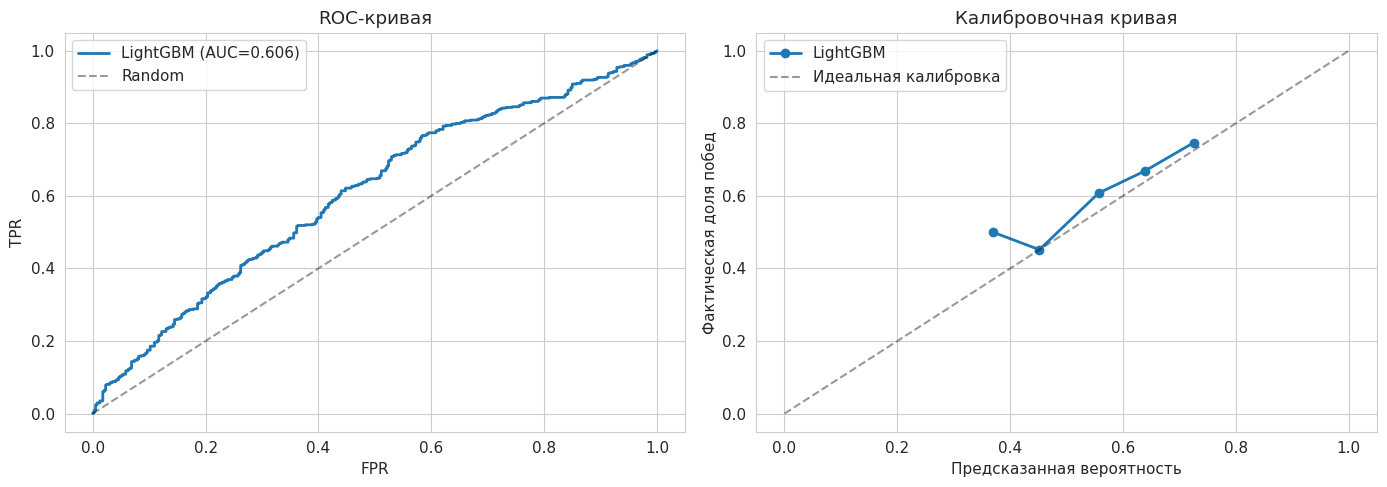

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, lw=2, label=f'LightGBM (AUC={roc_auc_score(y_test, proba_test):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()

pt, pp = calibration_curve(y_test, proba_test, n_bins=10)
axes[1].plot(pp, pt, marker='o', lw=2, label='LightGBM')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Идеальная калибровка')
axes[1].set_xlabel('Предсказанная вероятность')
axes[1].set_ylabel('Фактическая доля побед')
axes[1].set_title('Калибровочная кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

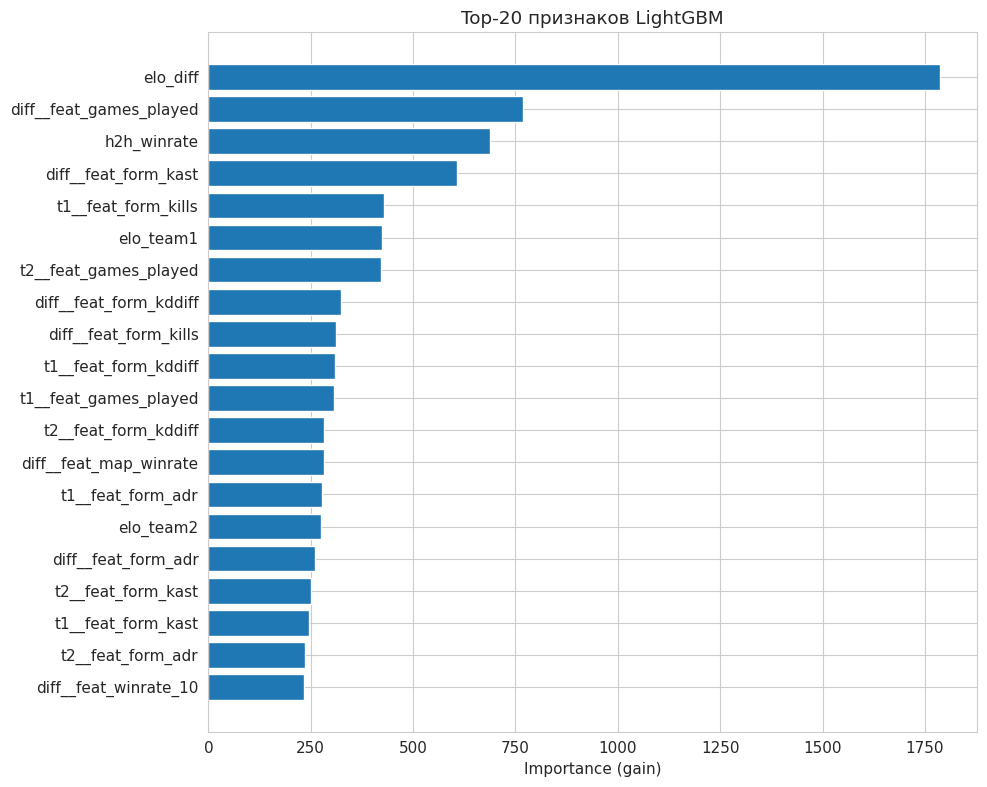

In [17]:
imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(imp['feature'], imp['importance'])
plt.xlabel('Importance (gain)')
plt.title('Top-20 признаков LightGBM')
plt.tight_layout()
plt.show()

 Функция предсказания для пары команд


In [20]:
MAP_POOL = ['Mirage', 'Inferno', 'Nuke', 'Ancient', 'Anubis', 'Dust2', 'Train']

def _latest_state(team):

    rows = long_df[long_df.team == team]
    return (rows.iloc[-1], len(rows)) if len(rows) else (None, 0)

def _h2h_between(a, b, n=10):

    hist = []
    for t1, t2, win in zip(maps_df.team1.values, maps_df.team2.values, maps_df.team1_win.values):
        if {t1, t2} == {a, b}:
            hist.append(t1 if win == 1 else t2)
    if not hist:
        return 0.5, 0, 0, 0
    recent = hist[-n:]
    wins_a = sum(1 for w in recent if w == a)
    return wins_a / len(recent), wins_a, len(recent) - wins_a, len(hist)

def _team_top_maps(team, n=5, min_games=3):

    rows = long_df[long_df.team == team]
    if len(rows) == 0:
        return pd.DataFrame()
    mp = rows.groupby('map_name').agg(games=('win', 'size'), winrate=('win', 'mean'))
    return mp[mp.games >= min_games].sort_values('winrate', ascending=False).head(n)

def _build_feature_row(team_a, team_b, map_name, bestOf, tier, as_team1=True):

    sa, _ = _latest_state(team_a)
    sb, _ = _latest_state(team_b)
    elo_a = final_elo.get(team_a, 1500)
    elo_b = final_elo.get(team_b, 1500)
    h2h, _, _, _ = _h2h_between(team_a, team_b)

    if as_team1:
        s1, s2, e1, e2, h = sa, sb, elo_a, elo_b, h2h
    else:
        s1, s2, e1, e2, h = sb, sa, elo_b, elo_a, 1 - h2h

    row = {c: 0 for c in feature_cols}
    for f in feat_names:
        v1 = s1.get(f) if s1 is not None else np.nan
        v2 = s2.get(f) if s2 is not None else np.nan
        if pd.isna(v1):
            v1 = median_fill.get(f't1__{f}', np.nan)
        if pd.isna(v2):
            v2 = median_fill.get(f't2__{f}', np.nan)
        row[f't1__{f}'] = v1
        row[f't2__{f}'] = v2
        d1 = v1 if pd.notna(v1) else 0
        d2 = v2 if pd.notna(v2) else 0
        row[f'diff__{f}'] = d1 - d2


    def _map_wr(team, mp):
        r = long_df[(long_df.team == team) & (long_df.map_name == mp)]
        return r['win'].tail(20).mean() if len(r) else 0.5

    a_mp = _map_wr(team_a if as_team1 else team_b, map_name)
    b_mp = _map_wr(team_b if as_team1 else team_a, map_name)
    row['t1__feat_map_winrate']   = a_mp
    row['t2__feat_map_winrate']   = b_mp
    row['diff__feat_map_winrate'] = a_mp - b_mp

    row['elo_team1']   = e1
    row['elo_team2']   = e2
    row['elo_diff']    = e1 - e2
    row['h2h_winrate'] = h

    if f'map_{map_name}' in row: row[f'map_{map_name}'] = 1
    if f'bo_{int(bestOf)}' in row: row[f'bo_{int(bestOf)}'] = 1
    if f'tier_{tier}' in row: row[f'tier_{tier}'] = 1

    return pd.DataFrame([row])[feature_cols].fillna(median_fill)

def predict_match(team_a, team_b, bestOf=3, tier='Tier1'):

    if team_a == team_b:
        raise ValueError('Команды должны быть разными')
    sa, n_a = _latest_state(team_a)
    sb, n_b = _latest_state(team_b)
    if sa is None: raise ValueError(f'Нет данных по команде «{team_a}»')
    if sb is None: raise ValueError(f'Нет данных по команде «{team_b}»')

    map_probs = {}
    for mp in MAP_POOL:
        X1 = _build_feature_row(team_a, team_b, mp, bestOf, tier, as_team1=True)
        X2 = _build_feature_row(team_a, team_b, mp, bestOf, tier, as_team1=False)
        p1 = float(model.predict(X1)[0])
        p2 = float(model.predict(X2)[0])
        map_probs[mp] = (p1 + (1 - p2)) / 2

    p_a = float(np.mean(list(map_probs.values())))
    h2h, wa, wb, tot = _h2h_between(team_a, team_b)

    def _form(s):
        out = {}
        for st in ['adr', 'kast', 'kills', 'kddiff']:
            v = s.get(f'feat_form_{st}') if s is not None else np.nan
            out[st] = float(v) if pd.notna(v) else np.nan
        return out

    def _safe(s, key):
        v = s.get(key) if s is not None else np.nan
        return float(v) if pd.notna(v) else np.nan

    return dict(
        team_a=team_a, team_b=team_b,
        p_a_win=p_a, p_b_win=1 - p_a,
        elo_a=final_elo.get(team_a, 1500),
        elo_b=final_elo.get(team_b, 1500),
        h2h=h2h, h2h_wins_a=wa, h2h_wins_b=wb, h2h_total=tot,
        form_a=_form(sa), form_b=_form(sb),
        wr50_a=_safe(sa, 'feat_winrate_50'),
        wr50_b=_safe(sb, 'feat_winrate_50'),
        wr10_a=_safe(sa, 'feat_winrate_10'),
        wr10_b=_safe(sb, 'feat_winrate_10'),
        games_a=n_a, games_b=n_b,
        map_probs=map_probs,
        top_maps_a=_team_top_maps(team_a),
        top_maps_b=_team_top_maps(team_b),
    )

#быстрый тест
r = predict_match('Team Vitality', 'Fnatic')
print(f"{r['team_a']}: {r['p_a_win']*100:.1f}%  vs  {r['team_b']}: {r['p_b_win']*100:.1f}%")
print(f"Elo {r['elo_a']:.0f} vs {r['elo_b']:.0f} | "
      f"WR-50 {r['wr50_a']*100:.1f}% vs {r['wr50_b']*100:.1f}% | "
      f"H2H {r['h2h_wins_a']}-{r['h2h_wins_b']} (всего {r['h2h_total']})")

Team Vitality: 67.3%  vs  Fnatic: 32.7%
Elo 2083 vs 1550 | WR-50 90.0% vs 46.0% | H2H 0-0 (всего 0)


##  Визуализация

In [21]:
def explain_prediction(r):

    a, b = r['team_a'], r['team_b']
    args = []

    d = r['elo_a'] - r['elo_b']
    if abs(d) >= 30:
        lead = a if d > 0 else b
        args.append(f"Elo: {lead} сильнее на {abs(d):.0f} очков ({r['elo_a']:.0f} vs {r['elo_b']:.0f}).")
    else:
        args.append(f"Elo практически равный ({r['elo_a']:.0f} vs {r['elo_b']:.0f}).")

    if pd.notna(r['wr50_a']) and pd.notna(r['wr50_b']):
        d = r['wr50_a'] - r['wr50_b']
        lead = a if d > 0 else b
        args.append(f"Winrate за последние 50 карт: {lead} ведёт "
                    f"({r['wr50_a']*100:.0f}% vs {r['wr50_b']*100:.0f}%).")

    if pd.notna(r['wr10_a']) and pd.notna(r['wr10_b']):
        d = r['wr10_a'] - r['wr10_b']
        if abs(d) >= 0.1:
            lead = a if d > 0 else b
            args.append(f"Текущая форма (WR за 10 карт): {lead} лучше "
                        f"({r['wr10_a']*100:.0f}% vs {r['wr10_b']*100:.0f}%).")

    fa, fb = r['form_a'], r['form_b']
    if pd.notna(fa['adr']) and pd.notna(fb['adr']):
        d = fa['adr'] - fb['adr']
        if abs(d) >= 2:
            lead = a if d > 0 else b
            args.append(f"ADR: {lead} наносит больше урона "
                        f"({fa['adr']:.1f} vs {fb['adr']:.1f}).")

    if r['h2h_total'] >= 3:
        if r['h2h_wins_a'] > r['h2h_wins_b']:
            args.append(f"История встреч: {a} выигрывает у {b} "
                        f"{r['h2h_wins_a']}-{r['h2h_wins_b']} из последних "
                        f"{r['h2h_wins_a']+r['h2h_wins_b']}.")
        elif r['h2h_wins_b'] > r['h2h_wins_a']:
            args.append(f"История встреч: {b} выигрывает у {a} "
                        f"{r['h2h_wins_b']}-{r['h2h_wins_a']} из последних "
                        f"{r['h2h_wins_a']+r['h2h_wins_b']}.")
        else:
            args.append(f"История встреч: равная, {r['h2h_wins_a']}-{r['h2h_wins_b']}.")
    elif r['h2h_total'] == 0:
        args.append('История личных встреч отсутствует — нейтрально.')

    return args


def render_prediction(r):
    a, b = r['team_a'], r['team_b']
    pa, pb = r['p_a_win'] * 100, r['p_b_win'] * 100
    winner = a if pa >= pb else b
    conf = max(pa, pb)

    # Заголовок

    print(f'   {a}   vs   {b}')

    print()
    print(f'  {a:<30s}  {pa:5.1f}%')
    bar_a = int(round(pa / 2))
    bar_b = 50 - bar_a

    print(f'  {b:<30s}  {pb:5.1f}%')
    print()
    print(f'  Прогноз: победитель — {winner} (уверенность {conf:.1f}%)')


    # Аргументы
    print('\n  Почему:')
    for i, line in enumerate(explain_prediction(r), 1):
        print(f'    {i}. {line}')

    # Графики
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Elo
    ax = axes[0, 0]
    ax.barh([a, b], [r['elo_a'], r['elo_b']], color=['#2a9d8f', '#e76f51'])
    ax.set_xlim(1200, max(r['elo_a'], r['elo_b']) + 150)
    ax.set_xlabel('Team Power Rating (Elo-based)')
    ax.set_title('Рейтинг силы команд')
    for i, v in enumerate([r['elo_a'], r['elo_b']]):
        ax.text(v + 5, i, f'{v:.0f}', va='center', fontweight='bold')

    #  Winrate общий и недавний
    ax = axes[0, 1]
    cats = ['WR 50 карт', 'WR 10 карт']
    va = [r['wr50_a'] * 100, r['wr10_a'] * 100]
    vb = [r['wr50_b'] * 100, r['wr10_b'] * 100]
    x = np.arange(len(cats))
    ax.bar(x - 0.2, va, 0.4, label=a, color='#2a9d8f')
    ax.bar(x + 0.2, vb, 0.4, label=b, color='#e76f51')
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel('%')
    ax.set_ylim(0, 100)
    ax.set_title('Winrate: общий и текущая форма')
    ax.legend()
    for i, (ia, ib) in enumerate(zip(va, vb)):
        if pd.notna(ia): ax.text(i - 0.2, ia + 1, f'{ia:.0f}%', ha='center', fontsize=9)
        if pd.notna(ib): ax.text(i + 0.2, ib + 1, f'{ib:.0f}%', ha='center', fontsize=9)

    #  Форма игроков
    ax = axes[1, 0]
    stats = ['adr', 'kast', 'kills', 'kddiff']
    labels = ['ADR', 'KAST', 'Kills', 'KD-diff']
    va = [r['form_a'].get(s) if pd.notna(r['form_a'].get(s)) else 0 for s in stats]
    vb = [r['form_b'].get(s) if pd.notna(r['form_b'].get(s)) else 0 for s in stats]
    x = np.arange(len(stats))
    ax.bar(x - 0.2, va, 0.4, label=a, color='#2a9d8f')
    ax.bar(x + 0.2, vb, 0.4, label=b, color='#e76f51')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title('Индивидуальная форма (среднее за 20 карт)')
    ax.legend()

    #  Вероятность по картам
    ax = axes[1, 1]
    maps = list(r['map_probs'].keys())
    probs_a = [r['map_probs'][m] * 100 for m in maps]
    probs_b = [100 - p for p in probs_a]
    y = np.arange(len(maps))
    ax.barh(y, probs_a, color='#2a9d8f', label=a)
    ax.barh(y, probs_b, left=probs_a, color='#e76f51', label=b)
    ax.set_yticks(y)
    ax.set_yticklabels(maps)
    ax.set_xlim(0, 100)
    ax.set_xlabel('%')
    ax.axvline(50, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('Вероятность победы по картам')
    ax.legend(loc='lower right')
    for i, p in enumerate(probs_a):
        ax.text(p / 2, i, f'{p:.0f}%', ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    plt.suptitle(f'{a} vs {b}', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

    # Топ-карты
    print('\n  Лучшие карты команд:')
    print(f'  {a}:')
    if len(r['top_maps_a']):
        for mp, row in r['top_maps_a'].iterrows():
            print(f"     {mp:<12s} {row['winrate']*100:5.1f}%  ({int(row['games'])} игр)")
    print(f'  {b}:')
    if len(r['top_maps_b']):
        for mp, row in r['top_maps_b'].iterrows():
            print(f"     {mp:<12s} {row['winrate']*100:5.1f}%  ({int(row['games'])} игр)")

## Сам результат - это интерактивная панель

Выбрать(вписать) две команды и нажать на predict

In [22]:

team_counts = long_df.groupby('team').size()
eligible_teams = sorted(team_counts[team_counts >= 10].index.tolist())
print(f'Команд с ≥10 картами: {len(eligible_teams)}')

default_a = 'Team Vitality' if 'Team Vitality' in eligible_teams else eligible_teams[0]
default_b = 'Fnatic'        if 'Fnatic'        in eligible_teams else eligible_teams[1]

dd_a = widgets.Combobox(
    options=eligible_teams, value=default_a,
    description='Команда A:', ensure_option=True,
    layout=widgets.Layout(width='380px'),
)
dd_b = widgets.Combobox(
    options=eligible_teams, value=default_b,
    description='Команда B:', ensure_option=True,
    layout=widgets.Layout(width='380px'),
)
dd_bo = widgets.Dropdown(
    options=[1, 3, 5], value=3, description='BestOf:',
    layout=widgets.Layout(width='200px'),
)
dd_tier = widgets.Dropdown(
    options=['Tier1', 'Tier2', 'Tier3'], value='Tier1', description='Tier:',
    layout=widgets.Layout(width='200px'),
)
btn = widgets.Button(
    description='Predict', button_style='success',
    layout=widgets.Layout(width='180px', height='40px'),
)
out = widgets.Output()

def on_click(_):
    with out:
        clear_output(wait=True)
        a, b = dd_a.value.strip(), dd_b.value.strip()
        if a not in eligible_teams:
            print(f'Команда «{a}» не найдена или сыграла <10 карт'); return
        if b not in eligible_teams:
            print(f'Команда «{b}» не найдена или сыграла <10 карт'); return
        if a == b:
            print('Выбери разные команды'); return
        try:
            r = predict_match(a, b, bestOf=dd_bo.value, tier=dd_tier.value)
            render_prediction(r)
        except Exception as e:
            print(f'Ошибка: {e}')

btn.on_click(on_click)

ui = widgets.VBox([
    widgets.HBox([dd_a, dd_b]),
    widgets.HBox([dd_bo, dd_tier, btn]),
    out,
])
display(ui)

on_click(None)

Команд с ≥10 картами: 174
